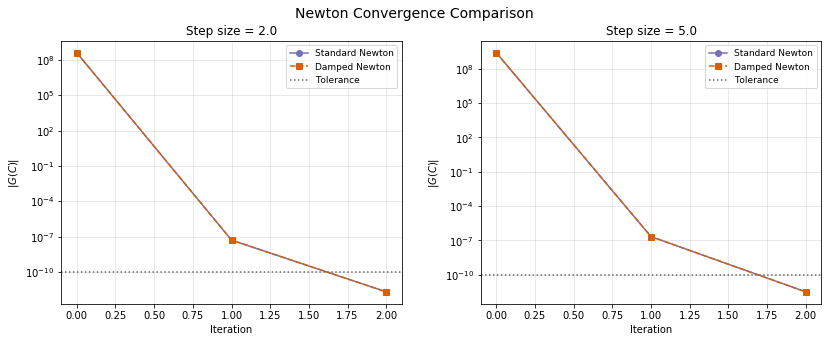

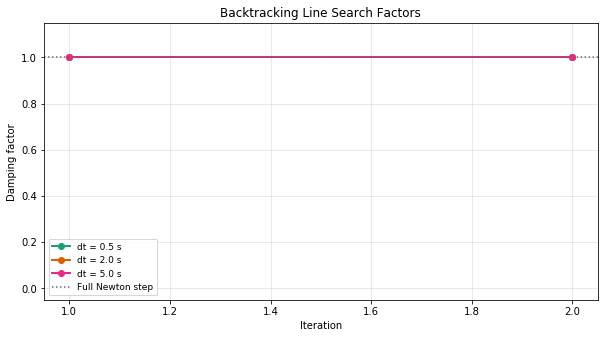

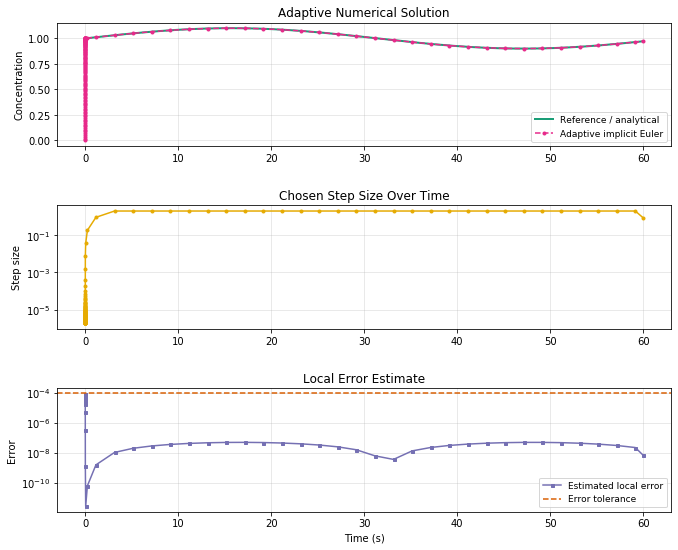

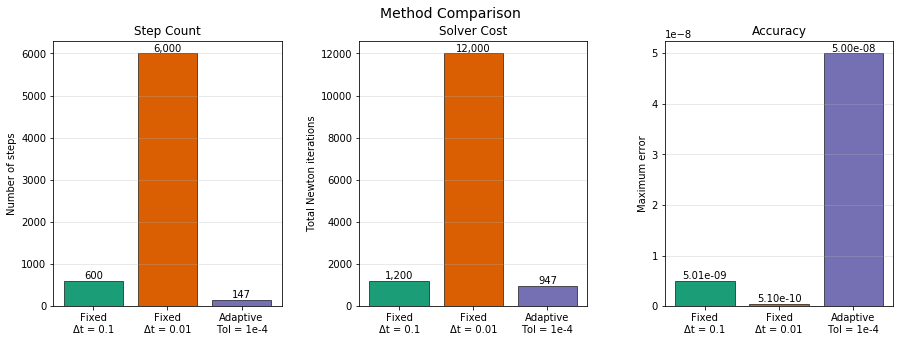

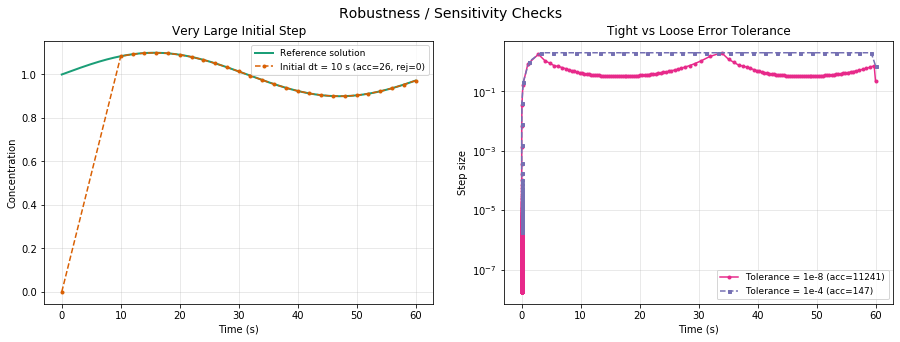

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

rate_const = 1e4
c_init = 0.0
t_final = 60.0

def ceq_profile(t):
    return 1.0 + 0.1 * np.sin(0.1 * t)

def ceq_profile_derivative(t):
    return 0.01 * np.cos(0.1 * t)

def ode_rhs(t, c):
    return -rate_const * (c - ceq_profile(t))

def reference_solution(t):
    return ceq_profile(t) - ceq_profile_derivative(t) / rate_const

def residual(c_next, c_now, t_next, dt):
    return c_next - c_now - dt * ode_rhs(t_next, c_next)

def residual_prime(dt):
    return 1.0 + dt * rate_const

def newton_with_backtracking(c_now, t_next, dt, tol=1e-10, max_iter=20, alpha_floor=1e-4):
    c_guess = c_now + dt * ode_rhs(t_next - dt, c_now)

    alpha_used = []
    total_halvings = 0

    for k in range(max_iter):
        r = residual(c_guess, c_now, t_next, dt)

        if abs(r) < tol:
            return c_guess, k + 1, True, alpha_used, total_halvings

        step = -r / residual_prime(dt)
        alpha = 1.0
        current_res = abs(r)
        halvings_this_iter = 0

        for _ in range(20):
            trial = c_guess + alpha * step
            if abs(residual(trial, c_now, t_next, dt)) < current_res:
                break
            alpha *= 0.5
            halvings_this_iter += 1

            if alpha < alpha_floor:
                alpha_used.append(alpha)
                total_halvings += halvings_this_iter
                return c_guess, k + 1, False, alpha_used, total_halvings

        alpha_used.append(alpha)
        total_halvings += halvings_this_iter
        c_guess = c_guess + alpha * step

    return c_guess, max_iter, False, alpha_used, total_halvings

def undamped_residual_history(c_now, t_next, dt, max_iter=15):
    c_guess = c_now + dt * ode_rhs(t_next - dt, c_now)
    hist = [abs(residual(c_guess, c_now, t_next, dt))]

    for _ in range(max_iter):
        r = residual(c_guess, c_now, t_next, dt)
        if abs(r) < 1e-10:
            break
        c_guess = c_guess - r / residual_prime(dt)
        hist.append(abs(residual(c_guess, c_now, t_next, dt)))

    return hist

def damped_residual_history(c_now, t_next, dt, max_iter=15):
    c_guess = c_now + dt * ode_rhs(t_next - dt, c_now)
    hist = [abs(residual(c_guess, c_now, t_next, dt))]
    alpha_hist = []

    for _ in range(max_iter):
        r = residual(c_guess, c_now, t_next, dt)
        if abs(r) < 1e-10:
            break

        step = -r / residual_prime(dt)
        alpha = 1.0
        current_res = abs(r)

        for __ in range(20):
            trial = c_guess + alpha * step
            if abs(residual(trial, c_now, t_next, dt)) < current_res:
                break
            alpha *= 0.5
            if alpha < 1e-4:
                break

        alpha_hist.append(alpha)
        c_guess = c_guess + alpha * step
        hist.append(abs(residual(c_guess, c_now, t_next, dt)))

    return hist, alpha_hist

def backward_euler_step(c_now, t_next, dt, tol=1e-10):
    c_next, iters, _, _, _ = newton_with_backtracking(c_now, t_next, dt, tol=tol)
    return c_next, iters

def doubled_step_estimate(c_now, t_now, dt, tol=1e-10):
    # one full step
    c_full, it1 = backward_euler_step(c_now, t_now + dt, dt, tol)

    # two half steps
    c_half1, it2 = backward_euler_step(c_now, t_now + dt / 2.0, dt / 2.0, tol)
    c_half2, it3 = backward_euler_step(c_half1, t_now + dt, dt / 2.0, tol)

    err_est = abs(c_half2 - c_full)
    return c_full, c_half2, err_est, (it1 + it2 + it3)

def choose_new_dt(dt, err, tol, safety=0.9, dt_min=1e-6, dt_max=2.0):
    if err < 1e-14:
        return min(2.0 * dt, dt_max)

    dt_new = safety * dt * np.sqrt(tol / err)
    dt_new = max(0.2 * dt, min(5.0 * dt, dt_new))
    return max(dt_min, min(dt_max, dt_new))

def solve_adaptive_ie(c0=None, t0=0.0, tf=t_final, dt0=0.1, tol=1e-4,
                      dt_min=1e-6, dt_max=2.0, safety=0.9, newton_tol=1e-10):

    if c0 is None:
        c0 = c_init

    t_vals = [t0]
    c_vals = [c0]
    dt_history = []
    err_history = []

    stats = {
        'accepted': 0,
        'rejected': 0,
        'newton_iters': 0,
        'function_calls': 0
    }

    t_now = t0
    c_now = c0
    dt = dt0

    while t_now < tf - 1e-12:
        dt = min(dt, tf - t_now)

        c_full, c_half, err, n_iter = doubled_step_estimate(c_now, t_now, dt, tol=newton_tol)

        stats['newton_iters'] += n_iter
        stats['function_calls'] += 2 * n_iter

        dt_next = choose_new_dt(dt, err, tol, safety, dt_min, dt_max)

        if err < tol:
            t_now += dt
            c_now = c_half

            t_vals.append(t_now)
            c_vals.append(c_now)
            dt_history.append(dt)
            err_history.append(err)

            stats['accepted'] += 1
        else:
            stats['rejected'] += 1

        dt = dt_next

    return np.array(t_vals), np.array(c_vals), np.array(dt_history), np.array(err_history), stats

def solve_adaptive_with_attempts(c0=None, t0=0.0, tf=t_final, dt0=0.5, tol=1e-4,
                                 dt_min=1e-6, dt_max=2.0, safety=0.9):

    if c0 is None:
        c0 = c_init

    t_vals = [t0]
    c_vals = [c0]

    trial_times = []
    trial_steps = []
    accepted_flags = []

    t_now = t0
    c_now = c0
    dt = dt0

    while t_now < tf - 1e-12:
        dt = min(dt, tf - t_now)

        c_full, c_half, err, _ = doubled_step_estimate(c_now, t_now, dt)
        dt_next = choose_new_dt(dt, err, tol, safety, dt_min, dt_max)

        accept = err < tol
        trial_times.append(t_now)
        trial_steps.append(dt)
        accepted_flags.append(accept)

        if accept:
            t_now += dt
            c_now = c_half
            t_vals.append(t_now)
            c_vals.append(c_now)

        dt = dt_next

    return (np.array(t_vals), np.array(c_vals),
            np.array(trial_times), np.array(trial_steps), np.array(accepted_flags))

def solve_fixed_ie(dt, t0=0.0, tf=t_final, c0=None):
    if c0 is None:
        c0 = c_init

    t_vals = np.arange(t0, tf + 0.5 * dt, dt)
    c_vals = np.zeros_like(t_vals)
    c_vals[0] = c0

    total_newton_iters = 0

    for n in range(len(t_vals) - 1):
        c_vals[n + 1], its, *_ = newton_with_backtracking(c_vals[n], t_vals[n + 1], dt)
        total_newton_iters += its

    return t_vals, c_vals, total_newton_iters

def max_error_after_startup(t_vals, c_vals):
    mask = t_vals > 1.0
    return np.max(np.abs(c_vals[mask] - reference_solution(t_vals[mask])))


t_dense = np.linspace(0.0, t_final, 5000)
c_dense = reference_solution(t_dense)

t_ad, c_ad, dt_ad, err_ad, stats_ad = solve_adaptive_ie(dt0=0.5, tol=1e-4)

t_fix1, c_fix1, it_fix1 = solve_fixed_ie(0.1)
t_fix2, c_fix2, it_fix2 = solve_fixed_ie(0.01)

t_big, c_big, _, _, stats_big = solve_adaptive_ie(dt0=10.0, tol=1e-4)
t_tight, c_tight, dt_tight, _, stats_tight = solve_adaptive_ie(dt0=0.1, tol=1e-8, dt_min=1e-10)
t_loose, c_loose, dt_loose, _, stats_loose = solve_adaptive_ie(dt0=0.1, tol=1e-4)

t_log, c_log, trial_t, trial_dt, trial_ok = solve_adaptive_with_attempts(dt0=0.5, tol=1e-4)

clr1 = '#1b9e77'   
clr2 = '#d95f02'   
clr3 = '#7570b3'   
clr4 = '#e7298a'   
clr5 = '#66a61e'   
clr6 = '#e6ab02'   
clr7 = '#a6761d'  
clr8 = '#666666'   
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9
})

fig1, ax = plt.subplots(1, 2, figsize=(12, 5))
fig1.suptitle("Newton Convergence Comparison", fontsize=14)

for axis, dt_test, title_txt in zip(
    ax,
    [2.0, 5.0],
    ["Step size = 2.0", "Step size = 5.0"]
):
    res_plain = undamped_residual_history(0.0, dt_test, dt_test)
    res_damped, _ = damped_residual_history(0.0, dt_test, dt_test)

    axis.semilogy(range(len(res_plain)), res_plain, marker='o', color=clr3, label='Standard Newton')
    axis.semilogy(range(len(res_damped)), res_damped, marker='s', linestyle='--', color=clr2, label='Damped Newton')
    axis.axhline(1e-10, linestyle=':', color=clr8, label='Tolerance')

    axis.set_xlabel("Iteration")
    axis.set_ylabel(r"$|G(C)|$")
    axis.set_title(title_txt)
    axis.grid(True, alpha=0.35)
    axis.legend()

plt.tight_layout(pad=2.5)
plt.savefig("theo_fig1_newton_compare.png", dpi=300)
plt.show()

fig2, ax2 = plt.subplots(figsize=(8.5, 4.8))

for dt_test, label_txt, col in zip(
    [0.5, 2.0, 5.0],
    ["dt = 0.5 s", "dt = 2.0 s", "dt = 5.0 s"],
    [clr1, clr2, clr4]
):
    _, alpha_vals = damped_residual_history(0.0, dt_test, dt_test)
    if alpha_vals:
        ax2.plot(range(1, len(alpha_vals) + 1), alpha_vals, marker='o', linewidth=2, color=col, label=label_txt)

ax2.axhline(1.0, linestyle=':', color=clr8, label='Full Newton step')
ax2.set_xlabel("Iteration")
ax2.set_ylabel("Damping factor")
ax2.set_title("Backtracking Line Search Factors")
ax2.set_ylim(-0.05, 1.15)
ax2.grid(True, alpha=0.35)
ax2.legend()

plt.tight_layout()
plt.savefig("theo_fig2_line_search.png", dpi=300)
plt.show()

fig3 = plt.figure(figsize=(11, 9))
gs = GridSpec(3, 1, figure=fig3, hspace=0.48)

ax3a = fig3.add_subplot(gs[0, 0])
ax3a.plot(t_dense, c_dense, color=clr1, linewidth=2, label='Reference / analytical')
ax3a.plot(t_ad, c_ad, color=clr4, linestyle='--', marker='.', label='Adaptive implicit Euler')
ax3a.set_ylabel("Concentration")
ax3a.set_title("Adaptive Numerical Solution")
ax3a.grid(True, alpha=0.35)
ax3a.legend()

ax3b = fig3.add_subplot(gs[1, 0])
ax3b.semilogy(t_ad[1:], dt_ad, color=clr6, marker='o', markersize=3)
ax3b.set_ylabel("Step size")
ax3b.set_title("Chosen Step Size Over Time")
ax3b.grid(True, alpha=0.35)

ax3c = fig3.add_subplot(gs[2, 0])
ax3c.semilogy(t_ad[1:], err_ad + 1e-17, color=clr3, marker='s', markersize=3, label='Estimated local error')
ax3c.axhline(1e-4, linestyle='--', color=clr2, label='Error tolerance')
ax3c.set_xlabel("Time (s)")
ax3c.set_ylabel("Error")
ax3c.set_title("Local Error Estimate")
ax3c.grid(True, alpha=0.35)
ax3c.legend()

plt.savefig("theo_fig3_adaptive_results.png", dpi=300)
plt.show()

performance = {
    'Fixed\nΔt = 0.1':  (len(t_fix1) - 1, it_fix1, max_error_after_startup(t_fix1, c_fix1)),
    'Fixed\nΔt = 0.01': (len(t_fix2) - 1, it_fix2, max_error_after_startup(t_fix2, c_fix2)),
    'Adaptive\nTol = 1e-4': (stats_ad['accepted'], stats_ad['newton_iters'], max_error_after_startup(t_ad, c_ad))
}

method_names = list(performance.keys())
step_counts = [performance[m][0] for m in method_names]
iter_counts = [performance[m][1] for m in method_names]
err_vals = [performance[m][2] for m in method_names]

bar_colors = [clr1, clr2, clr3]

fig4, ax4 = plt.subplots(1, 3, figsize=(13, 5))
fig4.suptitle("Method Comparison", fontsize=14)

plot_sets = [
    (step_counts, "Number of steps", "Step Count"),
    (iter_counts, "Total Newton iterations", "Solver Cost"),
    (err_vals, "Maximum error", "Accuracy")
]

for axis, (vals, ylab, title_txt) in zip(ax4, plot_sets):
    bars = axis.bar(method_names, vals, color=bar_colors, edgecolor='black', linewidth=0.6)
    axis.set_ylabel(ylab)
    axis.set_title(title_txt)
    axis.grid(True, axis='y', alpha=0.35)

    for bar, val in zip(bars, vals):
        if title_txt == "Accuracy":
            txt = f"{val:.2e}"
        else:
            txt = f"{int(val):,}"
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            txt,
            ha='center',
            va='bottom'
        )

plt.tight_layout(pad=2.5)
plt.savefig("theo_fig4_method_compare.png", dpi=300)
plt.show()

fig5, ax5 = plt.subplots(1, 2, figsize=(13, 5))
fig5.suptitle("Robustness / Sensitivity Checks", fontsize=14)

ax5[0].plot(t_dense, c_dense, color=clr1, linewidth=2, label='Reference solution')
ax5[0].plot(
    t_big, c_big,
    color=clr2, linestyle='--', marker='.',
    label=f'Initial dt = 10 s (acc={stats_big["accepted"]}, rej={stats_big["rejected"]})'
)
ax5[0].set_xlabel("Time (s)")
ax5[0].set_ylabel("Concentration")
ax5[0].set_title("Very Large Initial Step")
ax5[0].grid(True, alpha=0.35)
ax5[0].legend()

ax5[1].semilogy(
    t_tight[1:], dt_tight,
    color=clr4, marker='o', markersize=3,
    label=f'Tolerance = 1e-8 (acc={stats_tight["accepted"]})'
)
ax5[1].semilogy(
    t_loose[1:], dt_loose,
    color=clr3, linestyle='--', marker='s', markersize=3,
    label=f'Tolerance = 1e-4 (acc={stats_loose["accepted"]})'
)
ax5[1].set_xlabel("Time (s)")
ax5[1].set_ylabel("Step size")
ax5[1].set_title("Tight vs Loose Error Tolerance")
ax5[1].grid(True, alpha=0.35)
ax5[1].legend()

plt.tight_layout(pad=2.5)
plt.savefig("wd_robustness.png", dpi=300)
plt.show()